In [1]:
#Baseline Algorithms, Function Implementations
from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv(render_mode="None")
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()

<class 'type'>
0.16
0.48733693
0.60324436
0.6963208
0.85188586
0.827569
0.8849556
0.30086666
0.81573784
0.91483665
0.22196124
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [2]:
#Here we implement Baseline CGR as a function that can be called 
def BaselineCGR(env):
    
    init_observation,init_info=env.reset()
    #print(init_observation)
    delivery_ratio_metric=None
    contact_energy_efficiency=None
    total_reward=0
    done=False
    while not done:
        action = 1
        obs, reward, terminated, truncated, info = env.step(action)
        print(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    print("CGR")
    print(initial_data_volume)
    delivered_packets=info["Delivered Data"]
    print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    if((initial_data_volume*100)<delivered_packets):
        print("Delivery ratio error")
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()

    

In [3]:

def AdaptiveSorting(env):
    initial_observation,initial_information=env.reset()
    print(initial_observation)
    initial_data_volume=initial_observation[10]*100
    contacts_available=initial_observation[0:10]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    total_reward=0
  
    
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    #print("Initial Sorted Matrix")
    #print(sorted_matrix)
    remaining_data=initial_data_volume
    #print("Initial Data to send")
    #print(remaining_data)
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)):
        if (remaining_data>0):
            if sorted_matrix[i,0]<1:
                remaining_data=remaining_data-(10-sorted_matrix[i,0]*10)
                
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[i,1]
            else:
                decision_matrix[i,0]=0
                decision_matrix[i,1]=sorted_matrix[i,1]
        else:
            decision_matrix[i,0]=0
            decision_matrix[i,1]=sorted_matrix[i,1]
    #Next we must reorder the decision matrix
    

    #print("Decision Matrix")
    #print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    #print("Sorted Decisions")
    #print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)):
        action_decision_matrix[i]=sorted_decisions[i,0]
    #print("Actual set of Actions")
    #print(action_decision_matrix)
    obs=initial_observation
    i=0
    done=False
    while not done:
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
            print(action)
            total_reward+=reward
        else:
            #We use the contact
            
            action=1
            print(action)
            next_obs, reward, terminated, truncated, info = env.step(action)
            total_reward+=reward
            #Next we need to determine if we successfully delivered any packets
            current_delivered=next_obs[10]
            #print("Current_Delivered")
            #print(current_delivered)
            previous_delivered=obs[10]
            #print(previous_delivered)
            if (current_delivered<previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,10):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i+1):
                    aux_sorting_matrix[j,0]=1
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                aux_sorting_matrix=aux_sorting_matrix[aux_sorting_matrix[:, 0].argsort()]
                #print("Auxilliary Sorting Matrix")
                #print(aux_sorting_matrix)
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)):
                    if remaining_data>0:
                        if aux_sorting_matrix[j,0]<1:
                            remaining_data=remaining_data-(10-aux_sorting_matrix[j,0]*10)
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                        else:
                            decision_matrix[j,0]=0
                            decision_matrix[j,1]=aux_sorting_matrix[j,1]
                    else:
                        decision_matrix[j,0]=0
                        decision_matrix[j,1]=aux_sorting_matrix[j,1]

                aux_sorting_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(aux_sorting_decisions)):
                    action_decision_matrix[k]=aux_sorting_decisions[k,0]
                #print("New Decision Matrix")
                #print(action_decision_matrix)
        i+=1
        obs=next_obs
        done = terminated or truncated
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    print("Sorting Algo")
    print(initial_data_volume)
    delivered_packets=info["Delivered Data"]
    print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    if((initial_data_volume*100)<delivered_packets):
        print("Delivery ratio error")
    #print("Delivered Packets")
    #print(delivered_packets)
    #print("Number of Contacts")
    #print(number_of_contacts)
    #print("Initial Data Volume")
    #print(initial_data_volume)
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [4]:
#Basic debugging tests for sorting algorithm
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env)
print(total_reward)
total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env)
print(total_reward)

[0.8  0.1  0.4  0.4  0.6  0.8  0.2  0.5  0.4  0.4  0.41 0.  ]
0
1
0.41
0.79669714
0.9313776
0.54546607
0.16009349
0.64369446
0.66617376
0.64088446
0.55167544
0.03858977
0.70035505
1
0.32
0.055887554
0.65807587
0.45436153
0.35607672
0.60556686
0.7624157
0.7479883
0.17257176
0.6235161
0.39779377
1
0.26
0.14847802
0.4310593
0.9490127
0.22648928
0.1557179
0.28355134
0.17566997
0.47613618
0.7248582
0.9166186
0
0
1
0.21
0.6305739
0.5294555
0.3415316
0.06953966
0.8857864
0.68721324
0.94298905
0.77457386
0.84839493
0.3665363
1
0.12
0.54030263
0.6147097
0.49803758
0.83151567
0.44053292
0.49467847
0.6827867
0.7285909
0.3071777
0.92296857
1
0.06
0.69778687
0.7311241
0.46323282
0.8085416
0.280052
0.009833176
0.19854528
0.6436919
0.02310609
0.4748767
Sorting Algo
0.41
41
17.914458751678467
0.4
0.85455453
0.6908011
0.87055975
0.79939085
0.21306743
0.24872808
0.8434302
0.8229516
0.05892199
0.35938594
1
0.36
0.53543025
0.6034503
0.8897614
0.89671755
0.6914516
0.8308115
0.28417322
0.16246538
0.96596754

0.7
0.74762124
0.45118782
0.7627668
0.44169727
0.8998934
0.68118143
0.70643187
0.18394338
0.9350122
0.7016689
1
0.61
0.14391448
0.79196656
0.8930289
0.80192536
0.9989496
0.86588013
0.8998243
0.57141936
0.62722236
0.76874524
1
0.52
0.4891758
0.16214518
0.10556951
0.37955332
0.20913011
0.53923863
0.12583378
0.11550775
0.9862774
0.024818435
1
0.51
0.57545966
0.39869466
0.38943836
0.70780903
0.2682419
0.5367039
0.0013332368
0.56421757
0.6321672
0.913355
1
0.41
0.6129896
0.43177193
0.3058234
0.7494081
0.08071466
0.42733467
0.5422107
0.68640745
0.09632424
0.10756403
1
0.38
0.21376686
0.57320416
0.3051085
0.20446989
0.13195755
0.978865
0.11024274
0.038851697
0.41263178
0.99074894
1
0.36
0.99776083
0.99506277
0.51599365
0.5652451
0.72891587
0.25923708
0.8925386
0.4009128
0.9549412
0.37262484
1
0.33
0.34358647
0.42424196
0.4040906
0.15749975
0.36343473
0.02351897
0.32975128
0.36835134
0.6523234
0.9687149
1
0.33
0.62948024
0.6248532
0.20215856
0.2040165
0.40363458
0.57157654
0.446249
0.7854043
0

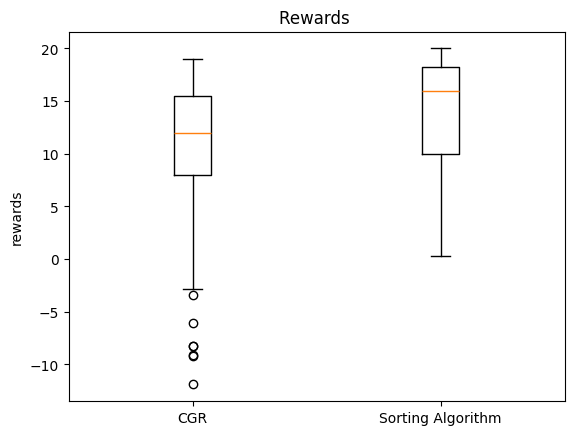

Mean Values
CGR delivery ratio
0.8271469583511353
Sorting delivery ratio
0.8378222455978394


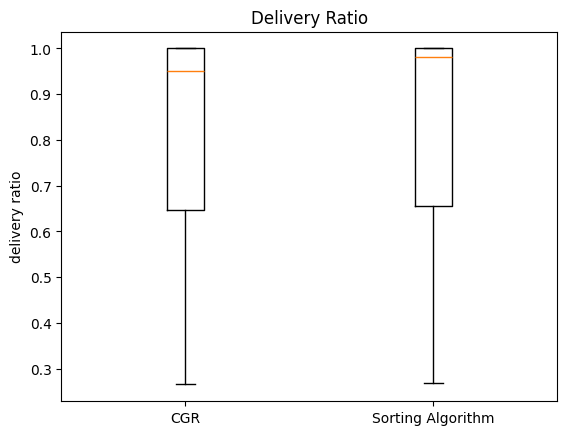

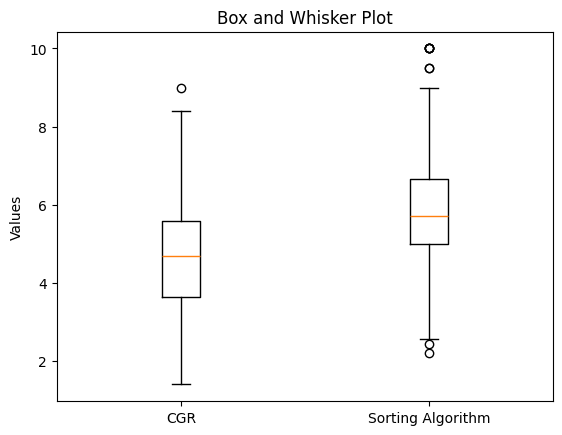

In [8]:
#Next we need to test these baseline algorithms and produce delivery, reward and contact energy efficiency
#graphs
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            env.reset(b)
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env)
          
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
#Next we must make box plots these results



#Adaptive sorting Algorithm

Sorting_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
Sorting_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            env.reset(b)
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env)
            Sorting_reward_vector[vector_index]=total_reward
            
            Sorting_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            print("Delivered Packets")
            print(delivered_packets)
            print("Initial Data Volume")
            print(initial_data_volume*100)
            print("Number of Contacts")
            print(number_of_contacts)
            Sorting_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts
            vector_index+=1
print("Sorting Delivery Ratio")
print(Sorting_delivery_ratio_vector)
print("CGR Delivery Ratio")
print(CGR_delivery_ratio_vector)
import matplotlib.pyplot as plt
#Reward Plot
#print("Sorting Reward")
#print(np.mean(Sorting_reward_vector))
#print(Sorting_reward_vector)
#print(CGR_reward_vector)
#print("CGR Reward")
print(np.mean(CGR_reward_vector))
plt.boxplot([CGR_reward_vector, Sorting_reward_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()
print("Mean Values")
print("CGR delivery ratio")
print(np.mean(CGR_delivery_ratio_vector))
print("Sorting delivery ratio")
print(np.mean(Sorting_delivery_ratio_vector))
#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, Sorting_delivery_ratio_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sorting_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Box and Whisker Plot")
plt.ylabel("Values")
plt.show()